## Práctica 6: DBSCAN - KMEANS - KMEANS+RKHS



Sistema de aprendizaje automático - C.E. Inteligencia Artificial y Big Data

In [17]:
#Importación de librerías
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import DBSCAN, KMeans
from sklearn.metrics import silhouette_score, calinski_harabasz_score
from sklearn.metrics import adjusted_rand_score, homogeneity_score, completeness_score, v_measure_score, normalized_mutual_info_score, adjusted_mutual_info_score
from sklearn.metrics.pairwise import rbf_kernel

# Tarea 1: Carga del dataset original y análisis inicial.

1.1. Carga el dataset indicado en un DataFrame de nombre dataset y muestra sus primeros
elementos. Muestra un análisis estadístico descriptivo de dataset. Representa gráficamente
dataset, usando un solo color, ya que sus puntos aún no están agrupados.

In [18]:
#Descargamos el dataset
!gdown 1jRCHr-Jo2WFhhdJXCpfm_T_dSJjI6OzI

Downloading...
From: https://drive.google.com/uc?id=1jRCHr-Jo2WFhhdJXCpfm_T_dSJjI6OzI
To: c:\Users\David\Desktop\IA y BigData\Sistema de aprendizaje automático\T6_Kmeans y RKHS\fuente\dataset_p6.csv

  0%|          | 0.00/61.0k [00:00<?, ?B/s]
100%|██████████| 61.0k/61.0k [00:00<00:00, 604kB/s]
100%|██████████| 61.0k/61.0k [00:00<00:00, 602kB/s]


In [19]:
#Lo cargamos
dataset = pd.read_csv('dataset_p6.csv', delimiter=',')
dataset.head()

,x,y
0,-1.214299,1.412649
1,1.908018,-0.443996
2,-0.123495,-1.970080
3,-1.674425,-1.139345
4,1.162182,1.606780


In [20]:
#Mostramos análisis estadístico
dataset.describe()

,x,y
count,1600.000000,1600.000000
mean,-0.015036,6.739025
std,10.889734,7.258496
min,-18.515338,-6.317141
25%,-7.464264,-0.081129
50%,-0.032261,7.507457
75%,7.621938,13.572895
max,18.538913,19.711485


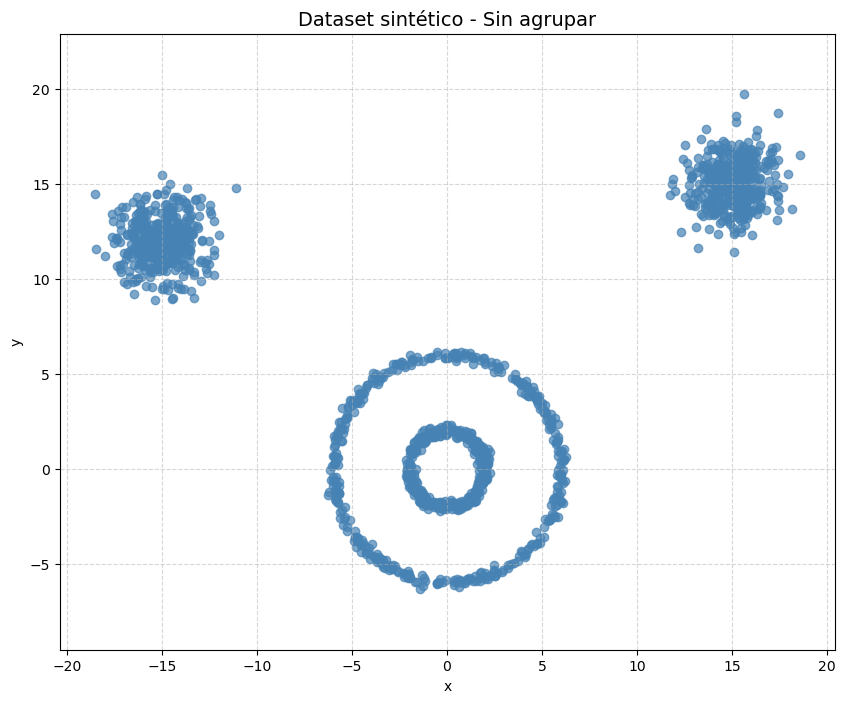

In [21]:
#Representamos gráficamente
plt.figure(figsize=(10, 8))
plt.scatter(dataset.iloc[:, 0], dataset.iloc[:, 1], c='steelblue', alpha=0.7)
plt.title('Dataset sintético - Sin agrupar', fontsize=14)
plt.xlabel(dataset.columns[0])
plt.ylabel(dataset.columns[1])
plt.grid(True, linestyle='--', alpha=0.5)
plt.axis('equal')
plt.show()

1.2. En un cuadro de texto, analiza el dataset, indicando sus características y haciendo una previsión justificada de los resultados que se pueden obtener agrupando ese dataset con los algoritmos DBSCAN, KMeans y KMeans-RKHS. Indica también si esperas que los índices
internos de validación Silhouette y Calinski-Harabasz reflejen correctamente la calidad visual del agrupamiento.

En el dataset podemos distinguir 4 formas geométricas diferenciadas entre ellas. 
Podemos observar dos nubes de puntos, uno de ellos situado en las coordenadas (-15, 12) y el otro en (15,15) aproximadamente.
Por otro lado, vemos también dos circunferencias concéntricas de las cuales una se encuentra dentro de la otra.
El rango de valores del eje x está entre -18.5 y 18.5, mientras que el rango de valores de y se encuentra entre -6.3 hasta 19.7

Viendo la distribución geométrica de este dataset, podemos hacer una previsión de resultados:
- El algoritmo DBSCAN, el cual se basa en la densidad de puntos, debería funcionar bien puesto que no se encuentran formas convexas, sienda capaz de reconocer correctamente los circulos concéntricos y las nubes de puntos si se ajusta correctamente los parametros eps y min_samples. A simple vista diría que DBSCAN encontraría 4 grupos

- El algoritmo Kmeans se basa en agrupamiento mediante distancias a centroides colocados de forma aleatoria, dividiendo el espacio del dataset en regiones lineales, haciendo que estructuras más complejas como los circulos concéntricos no queden correctamente identificados.

- El algoritmo Kmeans-RKHS puede proyectar los datos a un espacio de mayor dimensión, donde se pueden separar linealmente. Dependiendo del valor de gamma, se podría detectar las 4 formas geométricas.


En cuanto a los indices de validación, Silhouette mide la cohesión y separación de los clusters. Para este caso en el que todos los grupos parecen compactos, esperamos que el valor del índice de Silhouette sea cercano al 1.
Por otro lado, el índice de Calinski-Harabasz mide la dispersión de los puntos entre clústeres diferentes frente a la dispersión de los puntos dentro de un mismo clúster.

# Tarea 2: Clustering con DBSCAN

2.1. Aplica el algoritmo DBSCAN usando 6 valores distintos de eps y 3 valores distintos de
min_samples. Los resultados deberán representarse gráficamente en una cuadrícula de 6
filas (una por cada valor de eps) y 3 columnas (una por cada valor de min_samples). En cada
uno de los gráficos representados, el título deberá incluir tres filas con el siguiente
contenido: 
- a. DBSCAN: eps=eps ; min_samples=min_samples
- b. grupos=número_de_clústeres_obtenidos ; ruido=nº_de_puntos_ruido
- c. Silhouette=coeficiente_silhouette ; Calinski-Harabasz=calinski_harabasz

In [22]:
# Valores de hiperparametros a probar
eps = [0.5, 1.0, 1.3, 1.6, 2.0, 2.4]  # 6 valores de eps
min_samples = [3, 4, 5]  # 3 valores de min_samples

# Convertir dataset a numpy para usar con DBSCAN
X = dataset.values

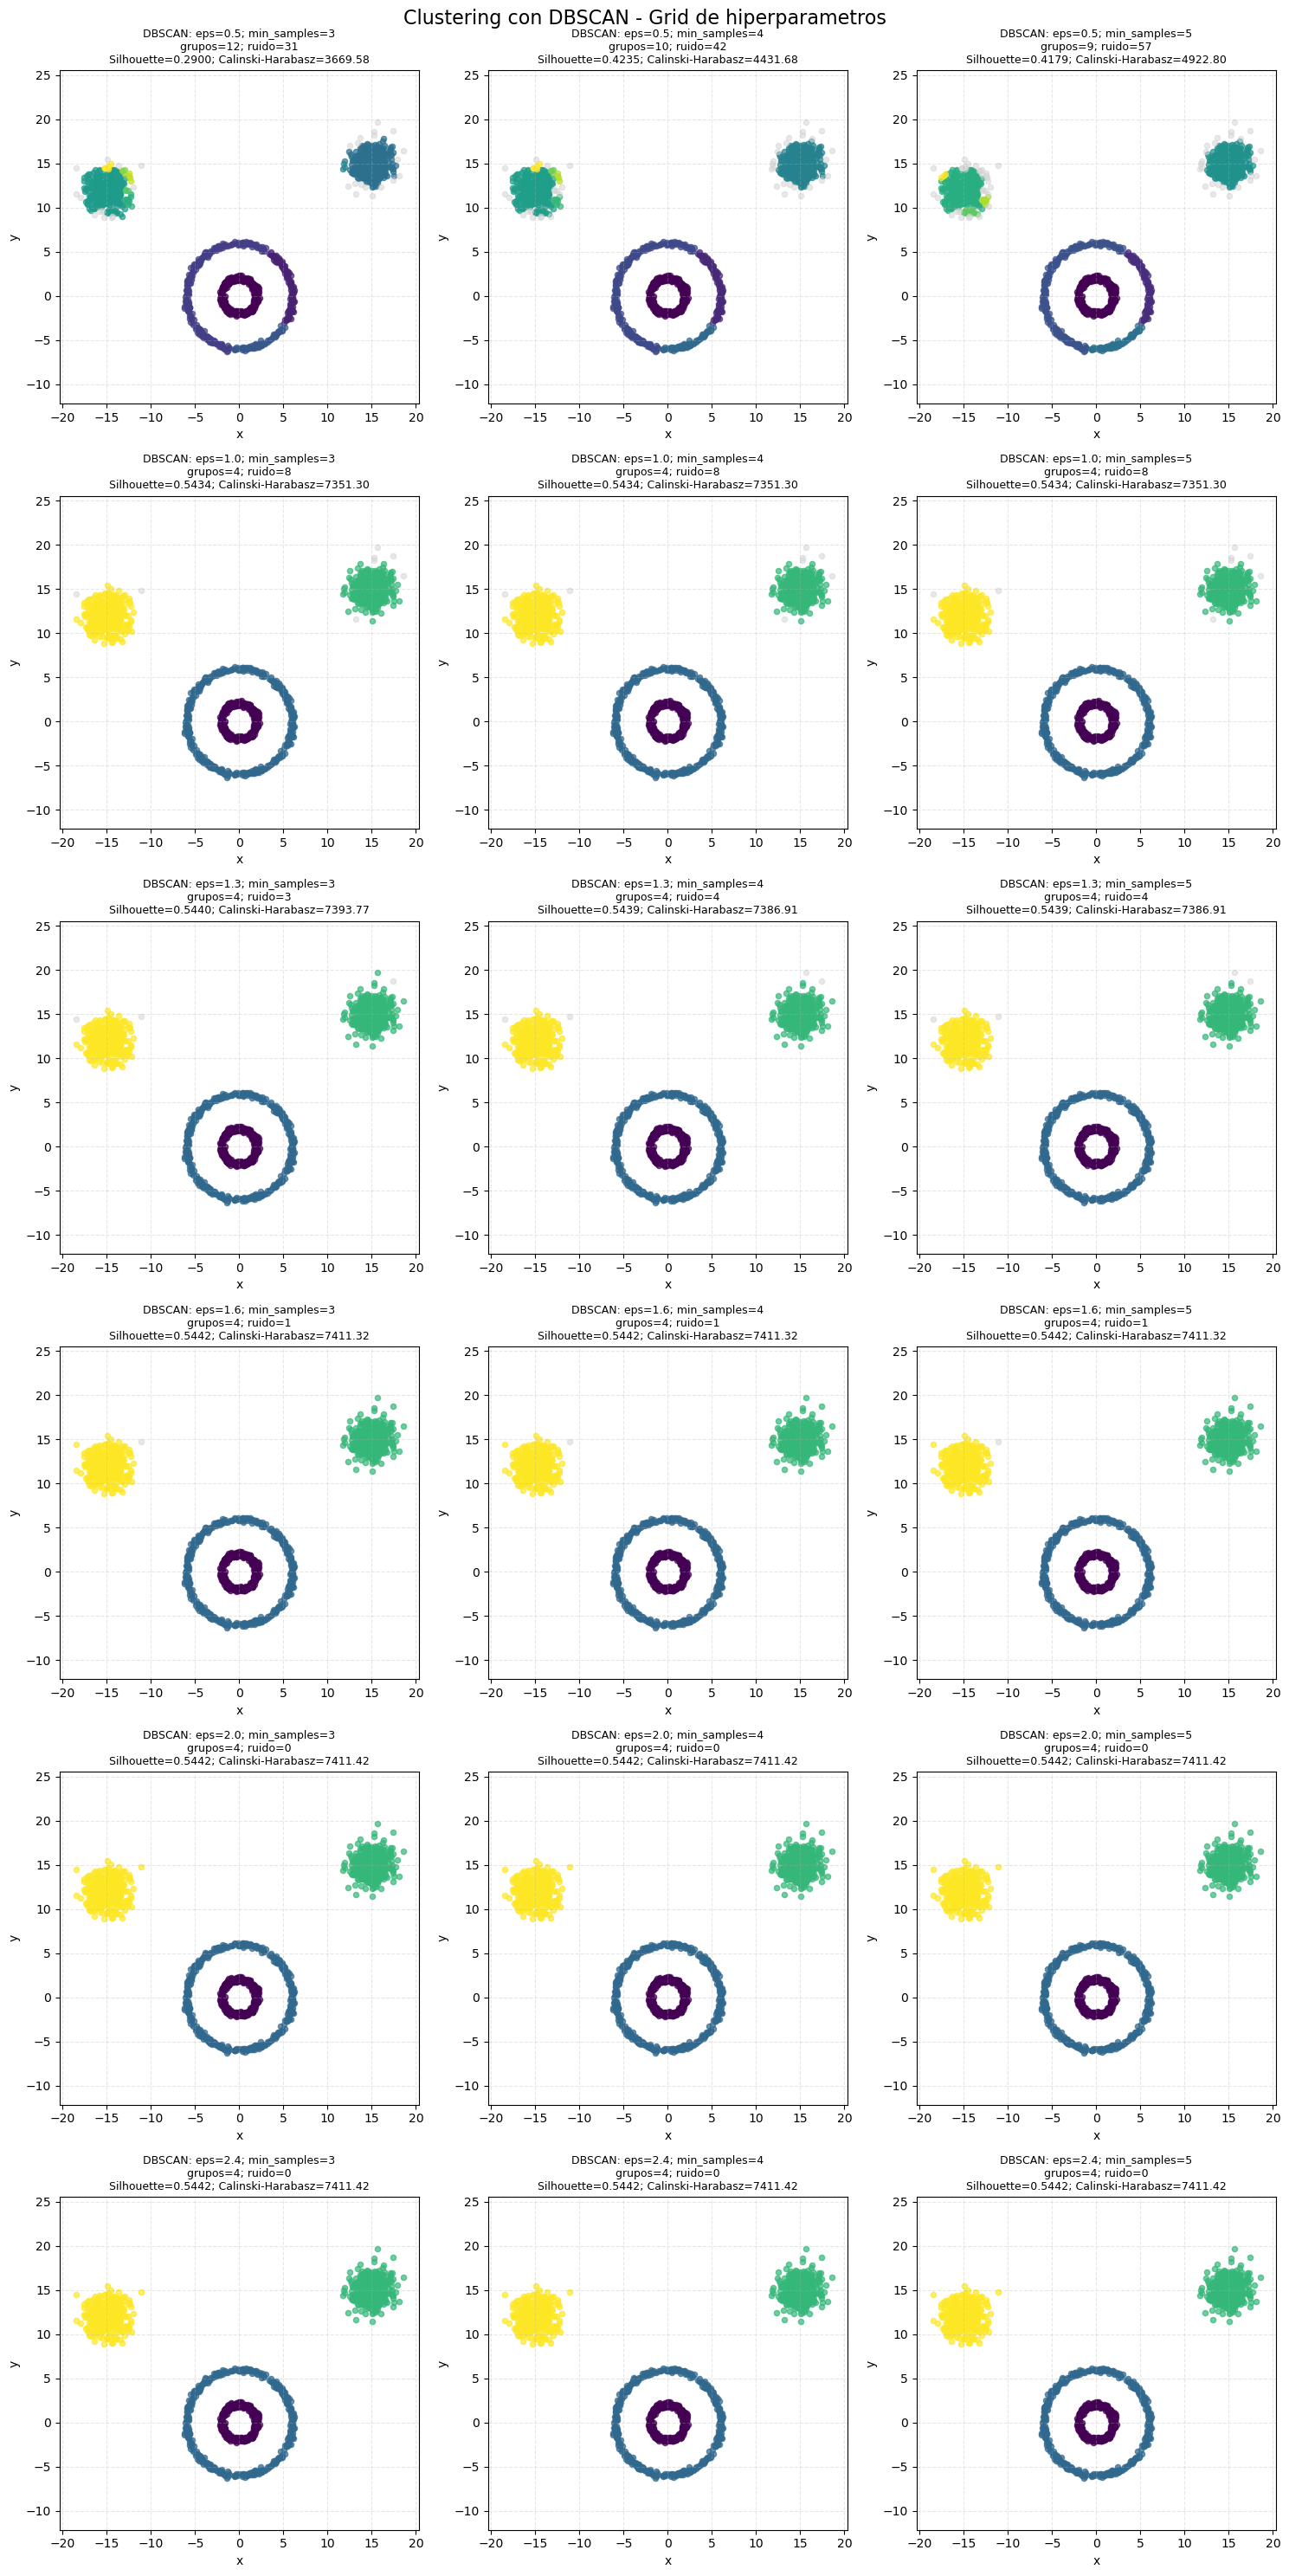

In [23]:
# Crear figura con cuadricula de 6x3
fig, axes = plt.subplots(6, 3, figsize=(15, 30))
fig.suptitle('Clustering con DBSCAN - Grid de hiperparametros', fontsize=16, y=0.99)

for i, eps in enumerate(eps):
    for j, min_samp in enumerate(min_samples):
        ax = axes[i, j]
        
        #Aplicar DBSCAN
        dbscan = DBSCAN(eps=eps, min_samples=min_samp)
        labels = dbscan.fit_predict(X)
        
        #Contar clusters (excluyendo ruido, label=-1)
        n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
        
        #Contar puntos de ruido
        n_noise = list(labels).count(-1)
        
        # Calcular indices solo sobre puntos no ruido
        mask = labels != -1 #Crea lista booleana
        if mask.sum() > 0 and n_clusters > 1: # Si mask.sum()>0 significa no hay ruido. n_cluster necesita al menos dos grupos
            silhouette = silhouette_score(X[mask], labels[mask])
            calinski = calinski_harabasz_score(X[mask], labels[mask])
            sil_str = f"{silhouette:.4f}"
            cal_str = f"{calinski:.2f}"
        else:
            silhouette = None
            calinski = None
            sil_str = "No definido"
            cal_str = "No definido"
        
        # Representacion grafica
        # Puntos de ruido en gris, clusters en colores
        colores = plt.cm.viridis(np.linspace(0, 1, max(n_clusters, 1)))
        
        for cluster_id in range(n_clusters):
            mask_cluster = labels == cluster_id
            ax.scatter(X[mask_cluster, 0], X[mask_cluster, 1], 
                     c=[colores[cluster_id]], s=20, alpha=0.7, label=f'Cluster {cluster_id}')
        
        # Puntos de ruido en gris claro
        mask_noise = labels == -1
        if mask_noise.sum() > 0:
            ax.scatter(X[mask_noise, 0], X[mask_noise, 1], 
                      c='lightgray', s=20, alpha=0.5, label='Ruido')
        
        # Titulo en 3 lineas
        ax.set_title(f"DBSCAN: eps={eps}; min_samples={min_samp}\n"
                    f"grupos={n_clusters}; ruido={n_noise}\n"
                    f"Silhouette={sil_str}; Calinski-Harabasz={cal_str}", 
                    fontsize=9)
        ax.set_xlabel('x')
        ax.set_ylabel('y')
        ax.axis('equal')
        ax.grid(True, linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()

2.2. En un cuadro de texto, analiza para qué rango de valores de los hiperparámetros el
algoritmo es capaz de reconocer las cuatro formas geométricas como grupos
independientes. Explica razonadamente por qué. Analiza también la relación de los dos
índices calculados con el resultado buscado, ¿son buenos esos índices para los resultados
que consideramos óptimos?

Basándonos en los resultados gráficos obtenidos, el algoritmo DBSCAN comienza a reconocer 4 formas geométricas como grupos independientes en el siguiente rango de valores:
- eps: desde 1,0 hasta 2,4. Aunque en determinados casos detecte mayor o menor ruido pero siempre 4 grupos.
- min_samples: en un rango de 3 hasta 5 y en combinación con los anteriores valores de eps, también se obtiene 4 grupos.

DBSCAN funciona bien cuando las formas geométricas tienen densidad suficiente y están bien definidos. El algoritmo identifica puntos núcleo que tienen al menos el número de min_samples puntos dentro de uun radio eps.

Tal y como podemos ver en nuestros gráficos, valores muy pequeños de eps genera muchos clústers y puntos ruidos ya que no encuentra puntos cercanos. Si por el contrario eps es muy grande los clústers podrían fusionarse.

Por otro lado, con valores pequños de min_samples se identifican más como puntos núcleo incluyendo posibles outliers, mientras que con valores grandes muchos puntos se identificarán como ruido, sobre todo en zonas menos densas.

Basándonos en los datos mostrados, el índice de silhouette mide la calidad del agrupamiento basándose en la dispersión de los clústers, el resultado obtenido para los 4 grupos, el índice de silhouette se encuentra alrededor de los 0.55 sindo un valor medianamente aceptable aunque no bueno del todo.

El índice de Calinski-Harabasz obtenemos un resultado aproximadamente del 7400, lo cual nos indica que hay una separación entre clústers y que la dispersión interna dentro de cada clúster es bajo.

# Tarea 3: Clustering con KMeans

3.1. Aplica el algoritmo KMeans para cuatro grupos. Representa gráficamente el resultado. El
gráfico debe incluir los centroides de los grupos, y el título del gráfico debe incluir dos filas,
con el siguiente contenido:
- a. KMeans con 4 grupos
- b. Silhouette=coeficiente_silhouette ; Calinski-Harabasz= calinski_harabasz

c:\Users\David\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=7.
  warnings.warn(


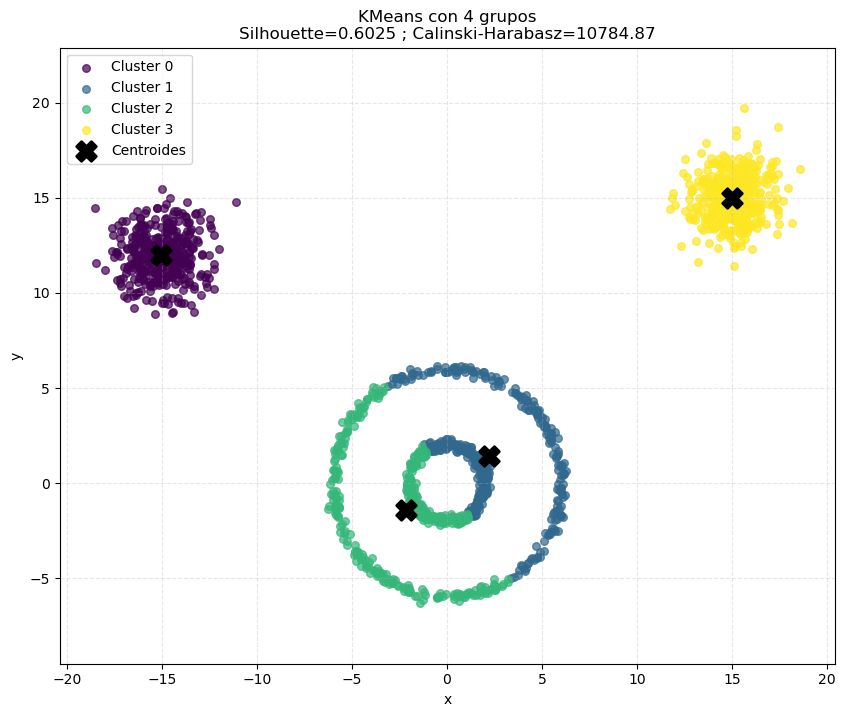

In [24]:
# Aplicar KMeans con 4 clusters
kmeans = KMeans(n_clusters=4, random_state=10, n_init=10)
labels_kmeans = kmeans.fit_predict(X)

# Obtener los centroides
centroides = kmeans.cluster_centers_

# Calcular indices de validacion
silhouette_kmeans = silhouette_score(X, labels_kmeans)
calinski_kmeans = calinski_harabasz_score(X, labels_kmeans)

# Representacion grafica
plt.figure(figsize=(10, 8))

# Colores para cada cluster
colores = plt.cm.viridis(np.linspace(0, 1, 4))

for i in range(4):
    mask = labels_kmeans == i
    plt.scatter(X[mask, 0], X[mask, 1], 
               c=[colores[i]], s=30, alpha=0.7, label=f'Cluster {i}')

# Marcar los centroides con una X negra
plt.scatter(centroides[:, 0], centroides[:, 1], 
           c='black', marker='X', s=200, linewidths=2, 
           label='Centroides', zorder=5)

# Titulo en 2 lineas
plt.title(f"KMeans con 4 grupos\n"
          f"Silhouette={silhouette_kmeans:.4f} ; Calinski-Harabasz={calinski_kmeans:.2f}", 
          fontsize=12)

plt.xlabel('x')
plt.ylabel('y')
plt.legend(loc='best')
plt.grid(True, linestyle='--', alpha=0.3)
plt.axis('equal')
plt.show()


3.2. En un cuadro de texto, analiza el resultado obtenido. ¿Consigue KMeans la agrupación
buscada? ¿Por qué? ¿Los índices obtenidos en el agrupamiento son buenos, o malos? ¿son
mejores estos índices que los obtenidos en los resultados que consideramos óptimos en la
agrupación de DBSCAN? ¿Por qué?

El algoritmo de KMeans no consigue la agrupación buscada en las 4 formas geométricas del dataset.
Podemos observar que las dos nubes de puntos sí han sido agrupadas correctamente mientras que los dos círculos concéntricos han sido agrupados dividiendolos linealmente por el centro.

¿Por qué sucede esto? Pues porque Kmeans funciona asumiendo que los clústers son con forma de nube o separables linealmente. Si en un caso como el nuestro en el que existen formas como lunas, espirales, formas irregulares o círculos concéntricos, Kmeans lo dividirá linealmente sin que coincida con la forma real del clúster.

Si analizamos los índices de silhouette y calinski-harabasz obtenemos buenos resultados que miden la calidad geométrica, pero no la calidad respecto a la forma real de los clusters.
El valor alto de estos índices indican que los agrupamientos son compactos y separados, pero no que hayan sido representado correctamente las 4 formas.


Podemos ver que los índices obtenidos son mejores que en el algoritmo DBSCAN puesto que sus valores son más altos, PERO vuelvo a recalcar que estos valores miden la calidad de densidad y dispersión del agrupamiento y no si el agrupamiento real es acertado o no

# Tarea 4: Clustering con KMeans-RKHS

4.1. Aplica el algoritmo KMeans-RKHS para cuatro grupos, usando 16 valores distintos de gamma.
Se deberán representar gráficamente los resultados en una cuadrícula de 4 filas por 4
columnas. Cada gráfica debe incluir los centroides de los grupos, y el título de cada gráfico
debe incluir tres filas, con el siguiente contenido:
- a. Agrupamiento con KMeans-RKHS
- b. 4 grupos, gamma=gamma
- c. Silhouette=coeficiente_silhouette ; Calinski-Harabasz= calinski_harabasz

c:\Users\David\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=7.
  warnings.warn(
c:\Users\David\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=7.
  warnings.warn(
c:\Users\David\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=7.
  warnings.warn(
c:\Users\David\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Window

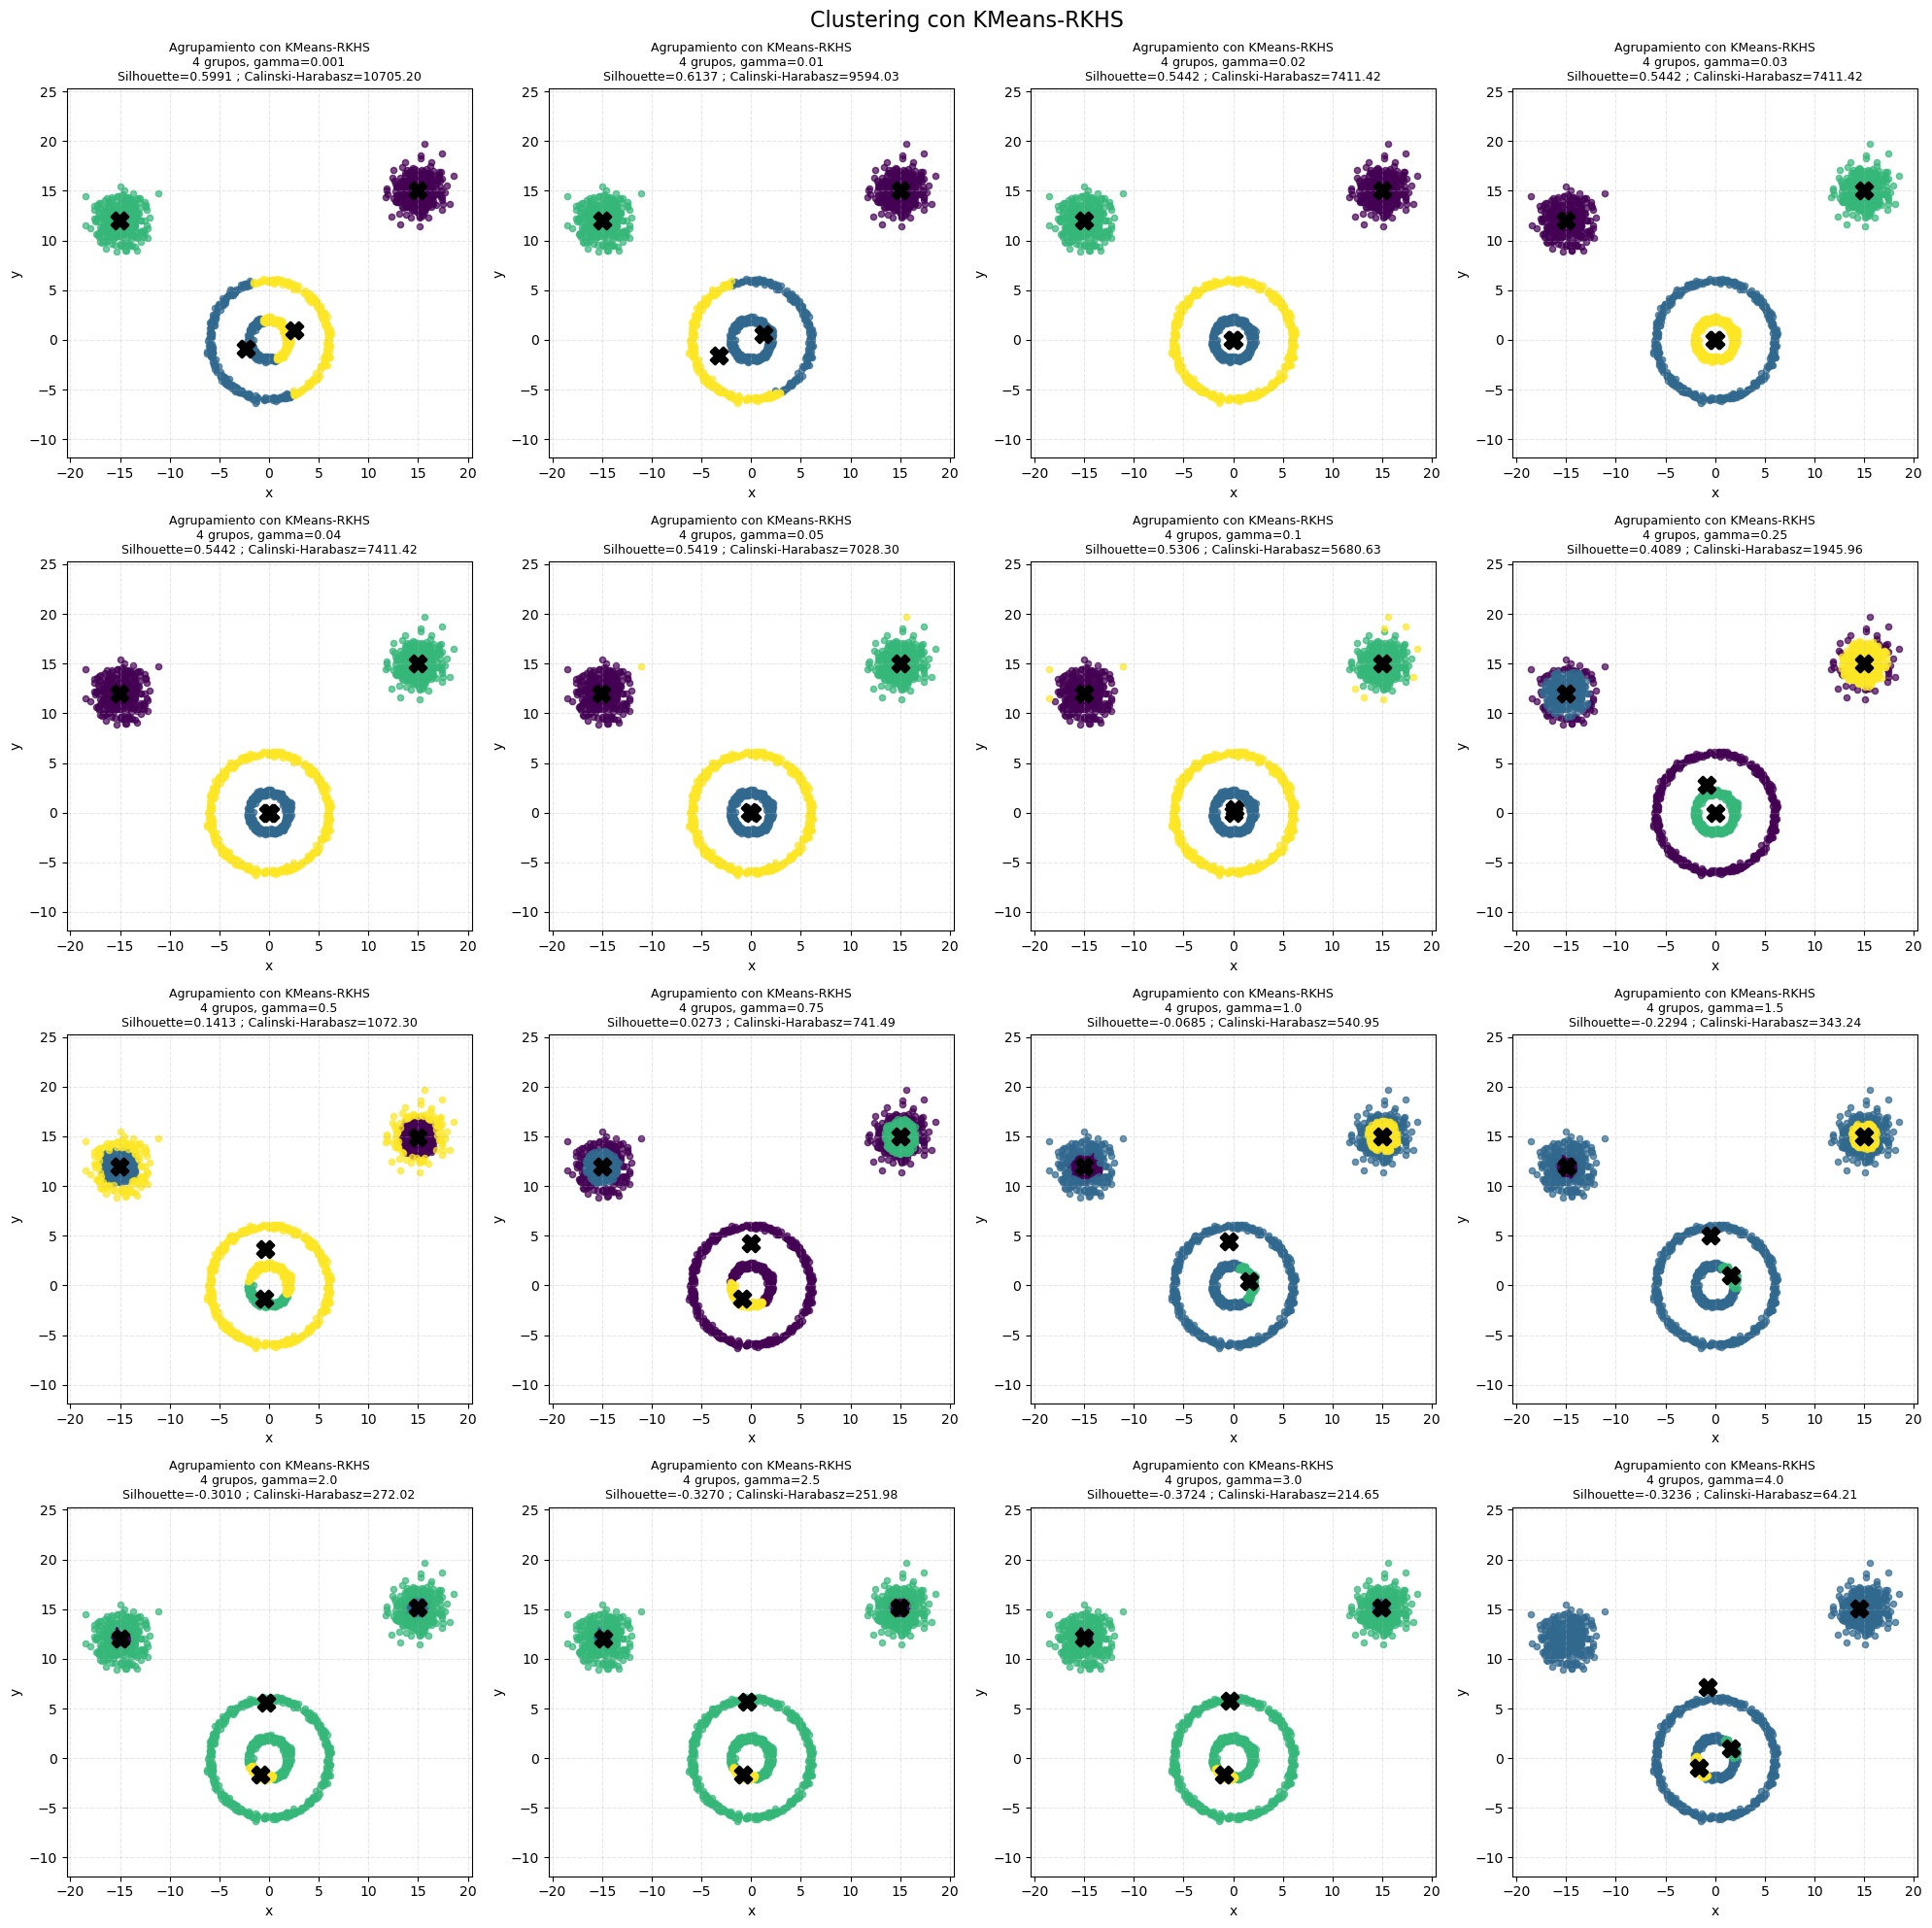

In [25]:
# Valores de gamma a probar (16 valores)
gamma_valores = [0.001, 0.01, 0.02, 0.03, 0.04, 0.05, 0.1, 0.25, 0.5, 0.75, 1.0, 
                1.5, 2.0, 2.5, 3.0, 4.0]
# Crear figura con cuadricula de 4x4
fig, axes = plt.subplots(4, 4, figsize=(20, 20))
fig.suptitle('Clustering con KMeans-RKHS', fontsize=16, y=0.99)

for indice, gamma in enumerate(gamma_valores):
    row = indice // 4
    col = indice % 4
    ax = axes[row, col]
    
    # Calcular la matriz de Gram (kernel RBF)
    Gram_matrix = rbf_kernel(X, gamma=gamma)
    
    # Aplicar KMeans sobre la matriz de Gram
    kmeans_rkhs = KMeans(n_clusters=4, random_state=10, n_init=10)
    labels_rkhs = kmeans_rkhs.fit_predict(Gram_matrix)
    
    # Calcular indices de validacion
    silhouette_rkhs = silhouette_score(X, labels_rkhs)
    calinski_rkhs = calinski_harabasz_score(X, labels_rkhs)
    
    # Calcular los centroides en el espacio original
    # (media de puntos de cada cluster en el espacio original)
    centroides_rkhs = np.array([X[labels_rkhs == i].mean(axis=0) for i in range(4)])# Para cada grupo, saca la media
    
    # Representacion grafica
    colors = plt.cm.viridis(np.linspace(0, 1, 4))
    
    for i in range(4):
        mask = labels_rkhs == i
        ax.scatter(X[mask, 0], X[mask, 1], 
                 c=[colors[i]], s=20, alpha=0.7, label=f'Cluster {i}')
    
    # Marcar los centroides
    ax.scatter(centroides_rkhs[:, 0], centroides_rkhs[:, 1], 
              c='black', marker='X', s=150, linewidths=2, 
              label='Centroides', zorder=5)
    
    # Titulo en 3 lineas
    ax.set_title(f"Agrupamiento con KMeans-RKHS\n"
                f"4 grupos, gamma={gamma}\n"
                f"Silhouette={silhouette_rkhs:.4f} ; Calinski-Harabasz={calinski_rkhs:.2f}", 
                fontsize=9)
    ax.set_xlabel('x')
    ax.set_ylabel('y')
    ax.axis('equal')
    ax.grid(True, linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()

4.2. En un cuadro de texto, analiza para qué rango de valores de gamma el algoritmo es capaz de
reconocer las cuatro formas geométricas como grupos independientes. Analiza la relación de
los dos índices calculados con el resultado buscado, ¿son mejores esos índices para los
resultados que consideramos óptimos que para el resto de resultados? ¿Por qué?

El algoritmo de Kmeans-RKHS reconoce correctamente los 4 clústers para un rango de gamma entre 0,02-0,04 siendo estos valores en los que el algoritmo agrupa correctamente todos los puntos en sus respectivos grupos.

Para este rango de valores de gamma se produce clustering óptimo, obteniendo valores de silhouette y calinski-harabasz más altos que con el resto de valores gamma. 

Si comparamos los resultados de los índices con los obtenidos en otros algoritmos, obtenemos resultados idénticos que los obtenidos con DBSCAN y muy similares al obtenido con Kmeans.

# Tarea 5: Entrenamiento final y validación externa entre algoritmos

5.1. Entrena finalmente el dataset con los tres algoritmos probados, usando los hiperparámetros
que optimicen nuestro objetivo. Construye el DataFrame agrupamientos, que contendrá a
dataset con tres columnas añadidas: dbscan, kmeans, kmeansRKHS, que contendrán el grupo
asignado a cada punto por el algoritmo indicado. Muestra el principio de agrupamientos.

In [26]:
# Hiperparámetros óptimos para DBSCAN. 
# De los gráficos obtenidos, hemos seleccionado, de los que no han producido ruido, el que sería uno de los valores centrales
mejor_eps = 2.4
mejor_min_samples= 3

# Hiperparámetros óptimos para Kmeans (K=4)
mejor_n_clusters = 4

# Hiperparámetros óptimos para Kmeans-rkhs
mejor_gamma = 0.03

In [27]:
#Aplicamos los hiperparámetros a los algoritmos
# DBSCAN con hiperparámetros optimos
dbscan_final = DBSCAN(eps=mejor_eps, min_samples=mejor_min_samples)
labels_dbscan = dbscan_final.fit_predict(X)

# KMeans con 4 grupos
kmeans_final = KMeans(n_clusters=mejor_n_clusters, random_state=10, n_init=10)
labels_kmeans_final = kmeans_final.fit_predict(X)

# KMeans-RKHS con el mejor gamma
Gram_matrix_final = rbf_kernel(X, gamma=mejor_gamma)
kmeans_rkhs_final = KMeans(n_clusters=mejor_n_clusters, random_state= 10, n_init=10)
labels_kmeans_rkhs_final = kmeans_rkhs_final.fit_predict(Gram_matrix_final)


c:\Users\David\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=7.
  warnings.warn(
c:\Users\David\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=7.
  warnings.warn(


In [28]:
# Copiar dataset y aniadir las columnas de agrupamiento
agrupamientos = dataset.copy()
agrupamientos['dbscan'] = labels_dbscan
agrupamientos['kmeans'] = labels_kmeans_final
agrupamientos['kmeansRKHS'] = labels_kmeans_rkhs_final

# Mostrar el principio del DataFrame
print("=== DataFrame agrupamientos (primeros 10 elementos) ===")
agrupamientos.head(10)


=== DataFrame agrupamientos (primeros 10 elementos) ===


,x,y,dbscan,kmeans,kmeansRKHS
0,-1.214299,1.412649,0,2,3
1,1.908018,-0.443996,0,1,3
2,-0.123495,-1.970080,0,2,3
3,-1.674425,-1.139345,0,2,3
4,1.162182,1.606780,0,1,3
5,1.094287,1.652612,0,1,3
6,1.882833,0.759976,0,1,3
7,1.422948,-1.746932,0,1,3
8,-1.732492,-1.389105,0,2,3
9,-0.206944,-1.819511,0,2,3


5.2. Representa gráficamente los 3 agrupamientos mostrando los 3 gráficos en una sola fila. Cada
gráfico tendrá las mismas características indicadas en los apartados anteriores.

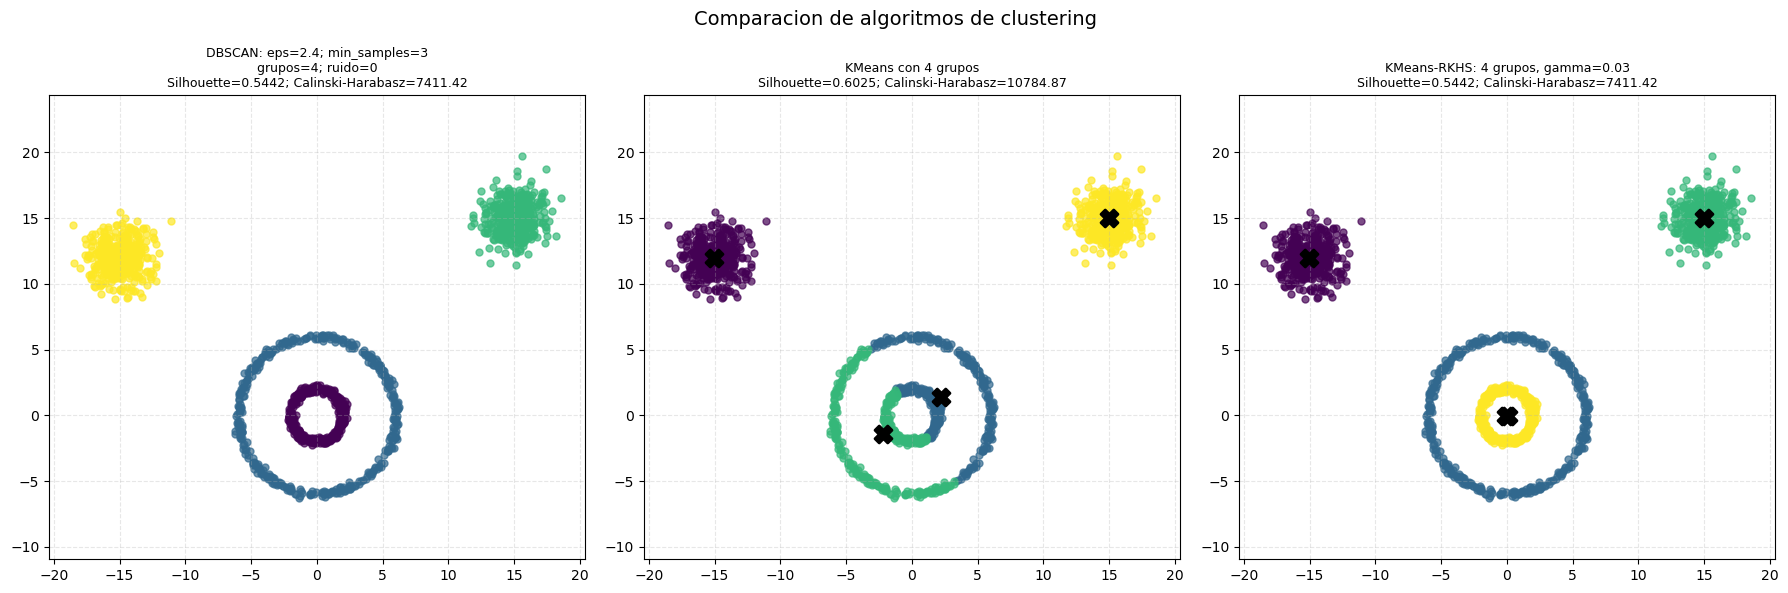

In [ ]:
# Crear figura con 3 graficos en una fila
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# DBSCAN
ax = axes[0]

n_clusters_dbscan = len(set(labels_dbscan)) - (1 if -1 in labels_dbscan else 0)
n_noise = list(labels_dbscan).count(-1) #Cuenta cuantos puntos tiene el label -1 (ruido)

mask_valid = labels_dbscan != -1
if mask_valid.sum() > 0 and n_clusters_dbscan > 1: #Verifica  si hay al menos un punto válido y al menos dos grupos para silhouette y calinski
    sil_dbscan = f"{silhouette_score(X[mask_valid], labels_dbscan[mask_valid]):.4f}"
    cal_dbscan = f"{calinski_harabasz_score(X[mask_valid], labels_dbscan[mask_valid]):.2f}"
else:
    sil_dbscan = cal_dbscan = "No definido"

colores = plt.cm.viridis(np.linspace(0, 1, max(n_clusters_dbscan, 1)))
for i in range(n_clusters_dbscan):
    ax.scatter(X[labels_dbscan == i, 0], X[labels_dbscan == i, 1], c=[colores[i]], s=25, alpha=0.7)
if -1 in labels_dbscan:
    ax.scatter(X[labels_dbscan == -1, 0], X[labels_dbscan == -1, 1], c='lightgray', s=25, alpha=0.5, label='Ruido')

ax.set_title(f"DBSCAN: eps={mejor_eps}; min_samples={mejor_min_samples}\n"
            f"grupos={n_clusters_dbscan}; ruido={n_noise}\n"
            f"Silhouette={sil_dbscan}; Calinski-Harabasz={cal_dbscan}", fontsize=9)
ax.axis('equal')
ax.grid(True, linestyle='--', alpha=0.3)

# KMEANS
ax = axes[1]

sil_kmeans = f"{silhouette_score(X, labels_kmeans_final):.4f}"
cal_kmeans = f"{calinski_harabasz_score(X, labels_kmeans_final):.2f}"

colores = plt.cm.viridis(np.linspace(0, 1, 4))
for i in range(4):
    ax.scatter(X[labels_kmeans_final == i, 0], X[labels_kmeans_final == i, 1], c=[colores[i]], s=25, alpha=0.7)

ax.scatter(kmeans_final.cluster_centers_[:, 0], kmeans_final.cluster_centers_[:, 1], 
        c='black', marker='X', s=150, linewidths=2, label='Centroides', zorder=5)

ax.set_title(f"KMeans con 4 grupos\n"
            f"Silhouette={sil_kmeans}; Calinski-Harabasz={cal_kmeans}", fontsize=9)
ax.axis('equal')
ax.grid(True, linestyle='--', alpha=0.3)


# KMEANS-RKHS
ax = axes[2]

sil_rkhs = f"{silhouette_score(X, labels_kmeans_rkhs_final):.4f}"
cal_rkhs = f"{calinski_harabasz_score(X, labels_kmeans_rkhs_final):.2f}"

colores = plt.cm.viridis(np.linspace(0, 1, 4))
for i in range(4):
    ax.scatter(X[labels_kmeans_rkhs_final == i, 0], X[labels_kmeans_rkhs_final == i, 1], c=[colores[i]], s=25, alpha=0.7)

centroides_rkhs = np.array([X[labels_kmeans_rkhs_final == i].mean(axis=0) for i in range(4)])
ax.scatter(centroides_rkhs[:, 0], centroides_rkhs[:, 1], c='black', marker='X', s=150, linewidths=2, label='Centroides', zorder=5)

ax.set_title(f"KMeans-RKHS: 4 grupos, gamma={mejor_gamma}\n"
            f"Silhouette={sil_rkhs}; Calinski-Harabasz={cal_rkhs}", fontsize=9)
ax.axis('equal')
ax.grid(True, linestyle='--', alpha=0.3)

plt.suptitle('Comparacion de algoritmos de clustering', fontsize=14)
plt.tight_layout()
plt.show()

5.3. A partir del dataframe agrupamientos, realiza una validación externa de los resultados de
agrupamiento utilizando todas las métricas vistas en clase: Rand Index ajustado (ARI),
homogeneidad, exhaustividad, V-Score, NMI y AMI. La comparación se llevará a cabo de
forma pareada, evaluando las coincidencias entre los siguientes pares de algoritmos:
DBSCAN vs KMeans, DBSCAN vs KMeans-RKHS y KMeans vs KMeans-RKHS. Los resultados
obtenidos deben almacenarse en un nuevo DataFrame, de nombre validacion_ext, donde
cada fila representará una comparación entre dos métodos de agrupamiento, con las
columnas siguientes:
- ○ Comparación: Nombre de los algoritmos comparados (por ejemplo, "DBSCAN vs
KMeans-RKHS")
- ○ ARI
- ○ Homogeneidad
- ○ Exhaustividad
- ○ V-Score
- ○ NMI
- ○ AMI

In [30]:
# Sacamos las etiquetas del dataframe agrupamientos
labels_dbscan = agrupamientos['dbscan'].values
labels_kmeans = agrupamientos['kmeans'].values
labels_kmeans_rkhs = agrupamientos['kmeansRKHS'].values
# Excluimos el ruido
mask_dbscan = labels_dbscan != -1

# Definimo las métricas y los nombres
metricas = [adjusted_rand_score, homogeneity_score, completeness_score, v_measure_score, normalized_mutual_info_score, adjusted_mutual_info_score]
nombres = ['ARI', 'Homogeneidad', 'Exhaustividad', 'V-Score', 'NMI', 'AMI']

# Definimos los pares
pares = [
    ('DBSCAN vs KMeans', labels_dbscan[mask_dbscan], labels_kmeans[mask_dbscan]),
    ('DBSCAN vs KMeans-RKHS', labels_dbscan[mask_dbscan], labels_kmeans_rkhs[mask_dbscan]),
    ('KMeans vs KMeans-RKHS', labels_kmeans, labels_kmeans_rkhs)
]

# DataFrame de validacion externa
validacion_ext = pd.DataFrame(index=nombres, columns=[pares[0][0], pares[1][0], pares[2][0]])
for nombre, metrica in zip(nombres, metricas):
    for nom, l1, l2 in pares:
        validacion_ext.loc[nombre, nom] = metrica(l1, l2)

validacion_ext


,DBSCAN vs KMeans,DBSCAN vs KMeans-RKHS,KMeans vs KMeans-RKHS
ARI,0.66666,1.0,0.66666
Homogeneidad,0.750326,1.0,0.750367
Exhaustividad,0.750367,1.0,0.750326
V-Score,0.750347,1.0,0.750347
NMI,0.750347,1.0,0.750347
AMI,0.749838,1.0,0.749838


5.4. Genera un gráfico de barras agrupado que muestre los valores de cada métrica para cada
comparación

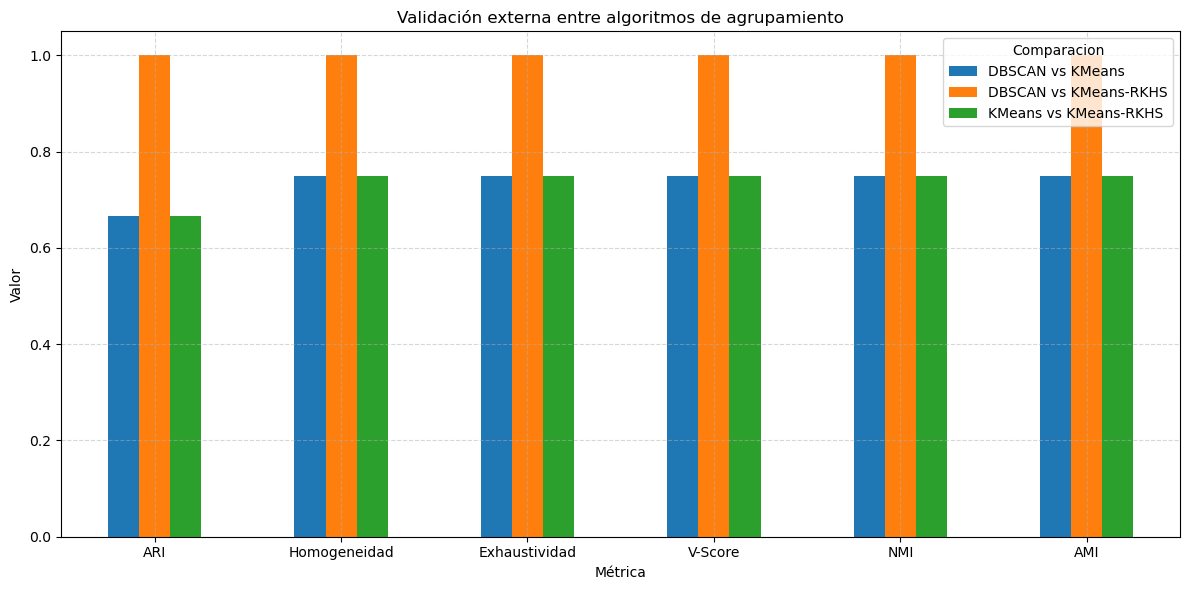

In [31]:
validacion_ext.plot(kind='bar', figsize=(12, 6))
plt.title('Validación externa entre algoritmos de agrupamiento')
plt.xlabel('Métrica')
plt.ylabel('Valor')
plt.legend(title='Comparacion')
plt.grid(True, linestyle='--', alpha=0.5)  
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

5.5. En un bloque de texto, incluye un análisis pormenorizado de los resultados obtenidos en la
validación externa.

DBSCAN vs KMeans:

Los resultados muestran una similitud moderada entre ambos algoritmos, aunque existen diferencias importantes.

El valor de ARI = 0.6667 indica que alrededor de dos tercios de las relaciones entre puntos coinciden en ambos agrupamientos. Esto significa que DBSCAN y KMeans encuentran ciertas similitudes en los datos, pero no generan exactamente los mismos clusters.

Las métricas de homogeneidad y exhaustividad, cercanas a 0.75, reflejan que:

- Los clusters creados por DBSCAN contienen mayoritariamente elementos de una misma clase, aunque no de forma perfecta.
Los elementos de una misma clase suelen agruparse juntos, pero también aparecen repartidos entre distintos clusters.

- El V-Score = 0.7503 resume este comportamiento mostrando una coincidencia parcial entre ambos métodos.

Además, los valores de NMI = 0.7503 y AMI = 0.7498 confirman que existe una relación clara entre los agrupamientos obtenidos, aunque la concordancia no es total.

En conjunto, estos resultados indican que KMeans no logra reproducir completamente la estructura geométrica que DBSCAN detecta en los datos.


DBSCAN vs KMeans-RKHS

En esta comparación aparece una concordancia prácticamente perfecta entre ambos algoritmos.

El dato más importante es el ARI = 1.0, lo que significa que todos los pares de puntos son agrupados exactamente de la misma manera en DBSCAN y KMeans-RKHS. En otras palabras, ambos generan prácticamente el mismo agrupamiento.

La homogeneidad = 1.0 y la exhaustividad = 1.0 indican que los clusters coinciden completamente tanto en composición como en distribución de las clases. Esto significa que cada cluster contiene únicamente elementos de una misma clase y que todos los elementos de cada clase se agrupan juntos sin dispersión entre distintos clusters.

En términos prácticos, esto demuestra que DBSCAN y KMeans-RKHS detectan la misma estructura geométrica subyacente en el dataset, a pesar de utilizar enfoques diferentes:

- DBSCAN se basa en densidad.
- KMeans-RKHS utiliza transformaciones mediante kernels.

KMeans vs KMeans-RKHS:

Los resultados son prácticamente idénticos a los obtenidos en la comparación entre DBSCAN y KMeans:

- ARI = 0.6667
- Homogeneidad = 0.75
- Exhaustividad = 0.75

Esto es muy significativo porque demuestra que DBSCAN y KMeans-RKHS producen agrupamientos equivalentes y que además KMeans se diferencia de ambos en la misma proporción.

Por tanto, se puede concluir que KMeans es el algoritmo que peor representa la estructura real de los datos, debido a que asume clusters convexos y esféricos, algo que no se adapta bien a este dataset.